# 👩‍💻 Build Your Own Perceptron for Binary Classification

## 📋 Overview
In this lab, you will implement a perceptron model from scratch for binary classification using PyTorch tensors. You'll generate synthetic data, train your model using the perceptron learning rule, visualize the decision boundary, and experiment with different learning rates. By building this fundamental neural network component yourself, you'll gain deeper insights into how neural networks learn and make predictions.

## 🎯 Learning Outcomes
By the end of this lab, you will be able to:

- Implement a perceptron model from scratch using PyTorch tensors
- Apply the perceptron learning rule to train a binary classifier
- Visualize decision boundaries and observe their evolution during training
- Analyze how different learning rates affect model convergence and performance

## 🚀 Starting Point
Access the starter code:

-  Use the provided Jupyter notebook

Required tools/setup:

- Python 3.6+
- PyTorch
- NumPy
- Matplotlib
- Scikit-learn

Make sure you understand:

- Basic tensor operations in PyTorch
- The perceptron model architecture discussed in previous lessons
- How to plot data using matplotlib

## Task 1: Dataset Setup
**Context:** Before building a classifier, you first need data. In real-world scenarios, data scientists often start with exploratory data analysis and visualization to understand the classification problem better.

**Steps:**

1. Import the necessary libraries
    - Use PyTorch (`torch`) for tensor operations
    - Use Scikit-learn's `make_classification` to generate synthetic data
    - Import matplotlib for visualization

In [1]:
# TODO: Import necessary libraries

import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.datasets import make_classification

2. Generate a synthetic binary classification dataset
    - Create 200 samples with 2 features using `make_classification`
    - Set `n_clusters_per_class=1` and `class_sep=2` to ensure good separation
    - Convert the NumPy arrays to PyTorch tensors

In [2]:
# TODO: Generate synthetic dataset and convert to PyTorch tensors
X_np, y_np = make_classification(
    n_samples=200, 
    n_features=2, 
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1, 
    class_sep=2,
    random_state=88
)

# Convert to PyTorch tensors
X = torch.tensor(X_np, dtype=torch.float32)
y = torch.tensor(y_np, dtype=torch.float32)

3. Visualize the dataset
    - Create a scatter plot showing the two classes in different colors
    - Add a legend and appropriate labels to the axes

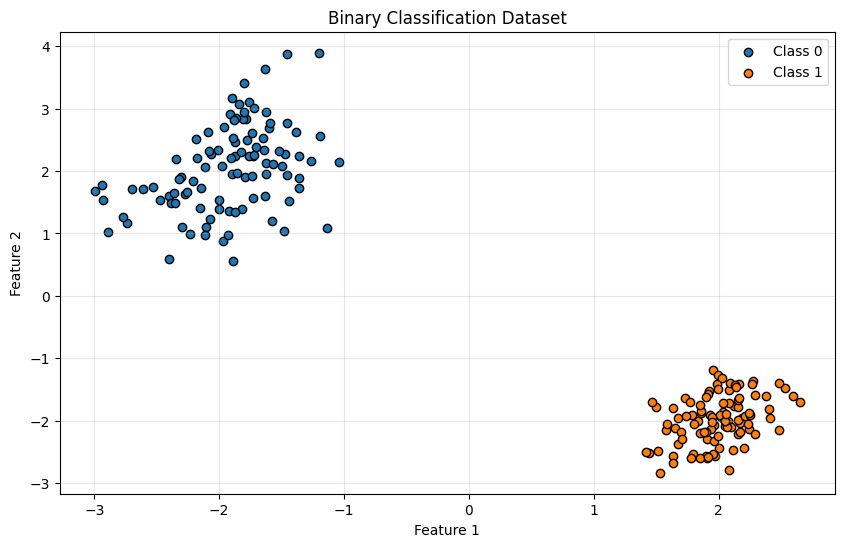

In [3]:
# TODO: Visualize dataset with different colors for each class
plt.figure(figsize=(10, 6))
for class_value in np.unique(y_np):
    plt.scatter(
        X_np[y_np == class_value, 0],
        X_np[y_np == class_value, 1],
        label=f'Class {class_value}',
        edgecolors='k'
    )

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Binary Classification Dataset')
plt.legend() 
plt.grid(True, alpha=0.3)
plt.show()

**💡 Tip:** When visualizing the data, consider using different markers or colors to make the class separation clear. This will help you verify if your perceptron can learn to separate these classes.

**⚙️ Test Your Work:**

- You should see a scatter plot with two clearly distinguishable groups of points
- Verify that you have 200 data points with 2 features (X shape should be [200, 2])
- Make sure your tensors have the correct data type (typically `torch.float32`)

## Task 2: Implementing the Perceptron
**Context:** In industry, understanding how models work "under the hood" is crucial for effective debugging and customization. Building a perceptron from scratch helps cement your understanding of the fundamental building block of neural networks.

**Steps:**

1. Create a Perceptron class
    - Initialize weights and bias as PyTorch tensors
    - Include parameters for input dimension and learning rate

In [ ]:
# TODO: Define Perceptron class with appropriate initialization

2. Implement the forward pass method
    - Calculate the weighted sum of inputs
    - Apply an activation function (e.g., sigmoid) to the sum
    - Return the prediction

In [ ]:
# TODO: Implement forward method for making predictions

3. Implement a method to update weights manually
    - Accept inputs and corresponding target values
    - Calculate prediction error
    - Update weights according to the perceptron learning rule

In [ ]:
# TODO: Implement weight update method based on perceptron learning rule

In [4]:
# Task 2: Implementing the Perceptron
class Perceptron:
    def __init__(self, input_dim, learning_rate=0.01):
        # Initialize weights and bias
        self.weights = torch.randn(input_dim, requires_grad=False) * 0.01
        self.bias = torch.zeros(1, requires_grad=False)
        self.learning_rate = learning_rate
        
    def forward(self, x):
        # Calculate the weighted sum and apply activation
        weighted_sum = torch.dot(self.weights, x) + self.bias
        return torch.sigmoid(weighted_sum)
    
    def predict(self, x):
        # Make binary prediction
        return 1 if self.forward(x) >= 0.5 else 0
    
    def update(self, x, target):
        # Calculate prediction and error
        prediction = self.forward(x)
        error = target - prediction
        
        # Update weights and bias using perceptron learning rule
        self.weights += self.learning_rate * error * x
        self.bias += self.learning_rate * error

**💡 Tip:** Remember that the perceptron learning rule updates weights proportionally to the error: Δw = learning_rate * error * input, where error = target - prediction.

**⚙️ Test Your Work:**

- Initialize your perceptron with random weights and verify they match the expected dimensions
- Pass a single input through the forward method and confirm you get a prediction between 0 and 1
- Test your weight update with a simple example to ensure weights change in the expected direction

## Task 3: Training the Perceptron
**Context:** Training neural networks is an iterative process where the model learns from examples over multiple passes through the dataset (epochs). Monitoring this process helps ensure the model is learning effectively.

**Steps:**

1. Implement the training loop
    - Loop through a specified number of epochs
    - For each epoch, iterate through all training examples
    - Call your weight update method for each example
    - Track metrics like accuracy or loss after each epoch

In [5]:
# TODO: Implement training loop with epoch iterations

def train_perceptron(model, X, y, epochs=20):
    accuracies = []
    stored_weights = []
    
    for epoch in range(epochs):
        # Create a permutation for shuffling
        indices = torch.randperm(len(X))
        
        # Training loop
        for i in indices:
            model.update(X[i], y[i])
        
        # Calculate and store accuracy
        accuracy = calculate_accuracy(model, X, y)
        accuracies.append(accuracy)
        
        # Store weights every 10 epochs
        if epoch % 2 == 0:
            stored_weights.append((epoch, model.weights.clone(), model.bias.clone()))
        
        if epoch % 2 == 0:
            print(f"Epoch {epoch}: Accuracy = {accuracy:.2f}%")
    
    return accuracies, stored_weights

2. Create a function to calculate accuracy
    - Convert continuous predictions to binary classes
    - Compare predictions with true labels
    - Calculate and return the accuracy percentage

In [6]:
# TODO: Implement function to calculate classification accuracy

def calculate_accuracy(model, X, y):
    correct = 0
    for i in range(len(X)):
        pred = model.predict(X[i])
        if pred == y[i]:
            correct += 1
    return correct / len(X) * 100

3. Train your perceptron
    - Initialize your model with appropriate parameters
    - Call the training function with your dataset
    - Print progress updates during training

Epoch 0: Accuracy = 100.00%
Epoch 2: Accuracy = 100.00%
Epoch 4: Accuracy = 100.00%
Epoch 6: Accuracy = 100.00%
Epoch 8: Accuracy = 100.00%
Epoch 10: Accuracy = 100.00%
Epoch 12: Accuracy = 100.00%
Epoch 14: Accuracy = 100.00%
Epoch 16: Accuracy = 100.00%
Epoch 18: Accuracy = 100.00%


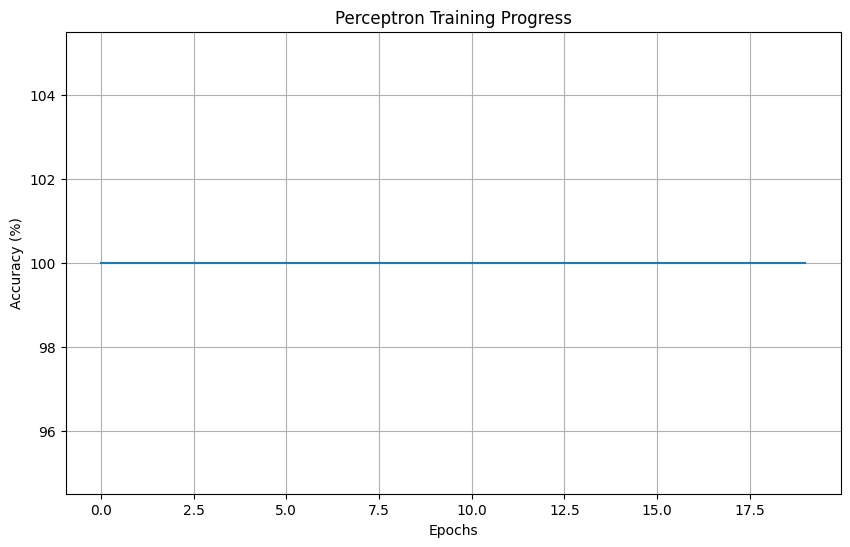

In [7]:
# TODO: Train the model and track progress

# Initialize and train perceptron
perceptron = Perceptron(input_dim=2, learning_rate=0.05)
accuracies, stored_weights = train_perceptron(perceptron, X, y)

# Plot accuracy over epochs
plt.figure(figsize=(10, 6))
plt.plot(accuracies)
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Perceptron Training Progress')
plt.grid(True)
plt.show()

**💡 Tip:** Consider shuffling your data before each epoch to prevent the model from learning patterns related to the order of examples.

**⚙️ Test Your Work:**

- You should see accuracy improving over epochs
- The final accuracy should be reasonably high (>90%) for this linearly separable dataset
- Verify weights are changing during training by printing them occasionally

## Task 4: Decision Boundary Visualization
**Context:** Visualizing machine learning models helps communicate results to stakeholders and provides insights into how the model makes decisions. For binary classifiers, the decision boundary is particularly informative.

**Steps:**

1. Create a function to plot the decision boundary
    - Generate a mesh grid covering the feature space
    - Make predictions for each point in the grid
    - Use `contourf()` or similar to plot the decision regions
    - Overlay the original data points

In [8]:
# TODO: Implement function to visualize decision boundary

def plot_decision_boundary(model, X, y, title="Decision Boundary"):
    # Create a mesh grid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    
    # Get predictions for each point in the mesh
    Z = np.zeros(xx.shape)
    for i in range(xx.shape[0]):
        for j in range(xx.shape[1]):
            point = torch.tensor([xx[i, j], yy[i, j]], dtype=torch.float32)
            Z[i, j] = model.forward(point).item()
    
    # Plot decision boundary
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap='viridis')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='k')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.colorbar()
    plt.show()

2. Visualize the trained model's decision boundary
    - Call your plotting function with the trained perceptron
    - Add appropriate labels and a title to the plot

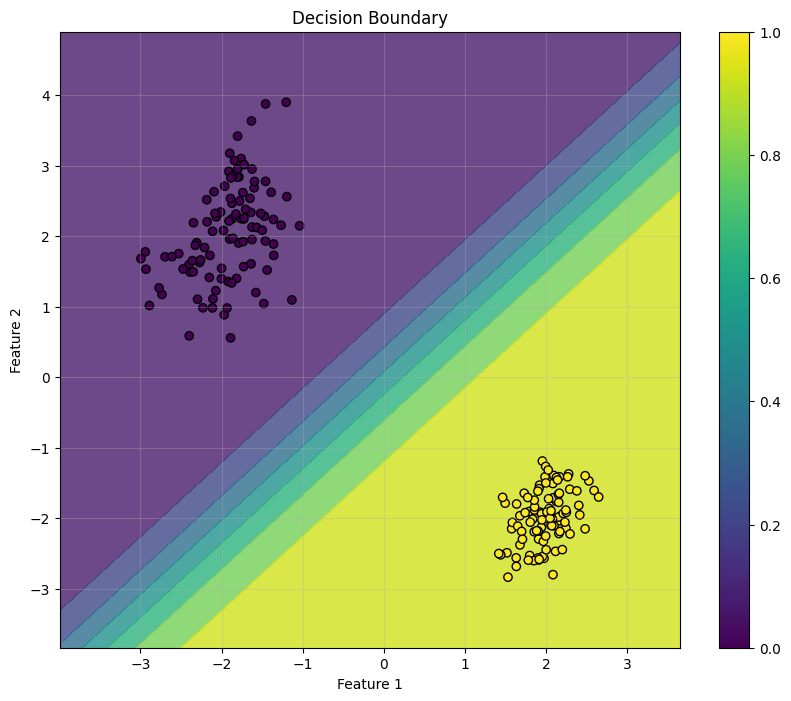

In [9]:
# TODO: Call visualization function with trained model
# Plot final decision boundary
plot_decision_boundary(perceptron, X_np, y_np)

3. Implement a function to visualize weights during training
    - Store weights at specific intervals during training
    - Plot how the weight values change over time

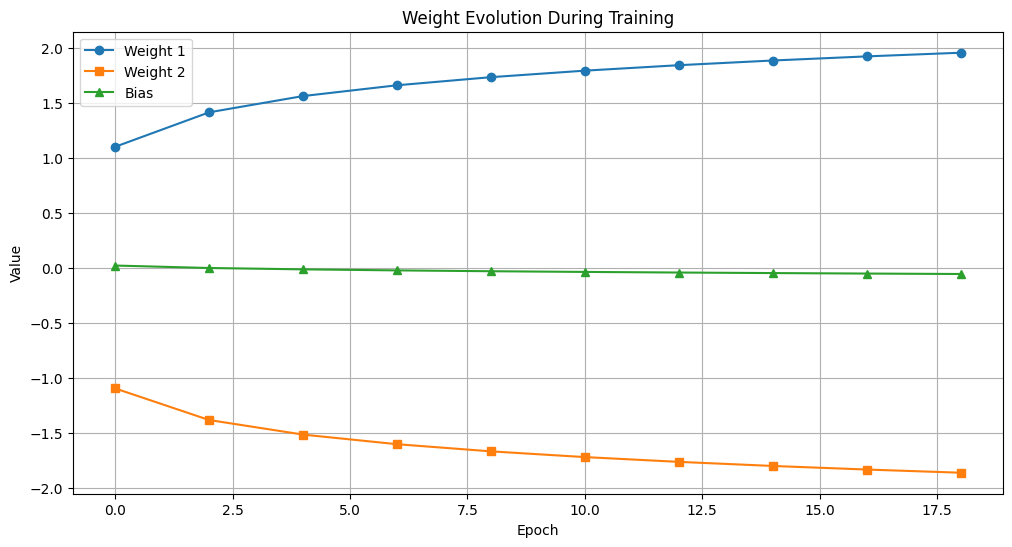

In [10]:
# TODO: Implement function to track and visualize weight evolution

# Visualize weight evolution
def plot_weight_evolution(stored_weights):
    epochs = [item[0] for item in stored_weights]
    w1_values = [item[1][0].item() for item in stored_weights]
    w2_values = [item[1][1].item() for item in stored_weights]
    bias_values = [item[2].item() for item in stored_weights]
    
    plt.figure(figsize=(12, 6))
    plt.plot(epochs, w1_values, 'o-', label='Weight 1')
    plt.plot(epochs, w2_values, 's-', label='Weight 2')
    plt.plot(epochs, bias_values, '^-', label='Bias')
    plt.xlabel('Epoch')
    plt.ylabel('Value')
    plt.title('Weight Evolution During Training')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_weight_evolution(stored_weights)

**💡 Tip:** For 2D data, the decision boundary is a line with the equation w₁x₁ + w₂x₂ + b = 0, where w₁ and w₂ are the weights and b is the bias.

**⚙️ Test Your Work:**

- The decision boundary should clearly separate the two classes
- The boundary visualization should match your intuition based on the data scatter plot
- The weight evolution plot should show convergence (stabilization) over time

## Task 5: Experimentation with Learning Rates
**Context:** Learning rate is a critical hyperparameter that affects how quickly and effectively a model learns. In production environments, finding the optimal learning rate can significantly impact model performance.

**Steps:**

1. Modify your training code to experiment with different learning rates
    - Create a list of learning rates to test (e.g., [0.001, 0.01, 0.1, 1.0])
    - Train separate models with each learning rate
    - Track and store training metrics for each


Training with learning rate: 0.001
Epoch 0: Accuracy = 100.00%
Epoch 2: Accuracy = 100.00%
Epoch 4: Accuracy = 100.00%
Epoch 6: Accuracy = 100.00%
Epoch 8: Accuracy = 100.00%
Epoch 10: Accuracy = 100.00%
Epoch 12: Accuracy = 100.00%
Epoch 14: Accuracy = 100.00%
Epoch 16: Accuracy = 100.00%
Epoch 18: Accuracy = 100.00%

Training with learning rate: 0.01
Epoch 0: Accuracy = 100.00%
Epoch 2: Accuracy = 100.00%
Epoch 4: Accuracy = 100.00%
Epoch 6: Accuracy = 100.00%
Epoch 8: Accuracy = 100.00%
Epoch 10: Accuracy = 100.00%
Epoch 12: Accuracy = 100.00%
Epoch 14: Accuracy = 100.00%
Epoch 16: Accuracy = 100.00%
Epoch 18: Accuracy = 100.00%

Training with learning rate: 0.1
Epoch 0: Accuracy = 100.00%
Epoch 2: Accuracy = 100.00%
Epoch 4: Accuracy = 100.00%
Epoch 6: Accuracy = 100.00%
Epoch 8: Accuracy = 100.00%
Epoch 10: Accuracy = 100.00%
Epoch 12: Accuracy = 100.00%
Epoch 14: Accuracy = 100.00%
Epoch 16: Accuracy = 100.00%
Epoch 18: Accuracy = 100.00%

Training with learning rate: 1.0
Epoch 

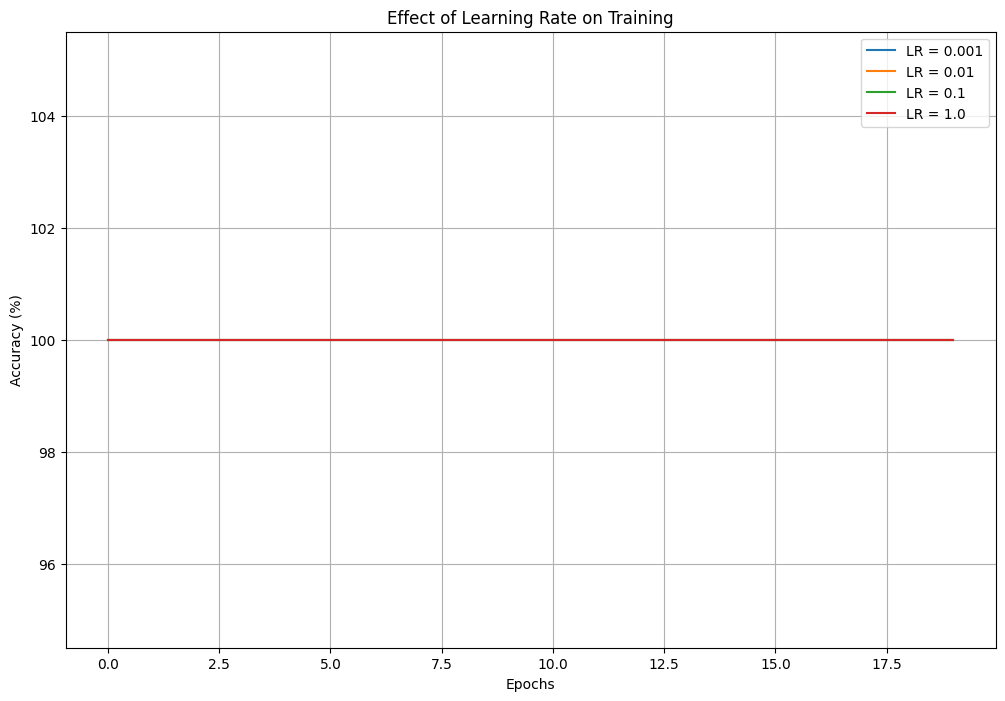

In [12]:
# TODO: Implement learning rate experiment

# Task 5: Experimentation with Learning Rates
def experiment_with_learning_rates(X, y, learning_rates):
    results = {}
    
    for lr in learning_rates:
        print(f"\nTraining with learning rate: {lr}")
        model = Perceptron(input_dim=2, learning_rate=lr)
        accuracies, _ = train_perceptron(model, X, y, epochs=20)
        results[lr] = {
            'model': model,
            'accuracies': accuracies
        }
    
    return results

# Run experiments with different learning rates
learning_rates = [0.001, 0.01, 0.1, 1.0]
experiment_results = experiment_with_learning_rates(X, y, learning_rates)

# Plot comparison of learning rates
plt.figure(figsize=(12, 8))
for lr, result in experiment_results.items():
    plt.plot(result['accuracies'], label=f'LR = {lr}')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Effect of Learning Rate on Training')
plt.legend()
plt.grid(True)
plt.show()

2. Visualize the impact of learning rates
    - Create a plot comparing accuracy over epochs for different learning rates
    - Plot decision boundaries for models trained with different rates

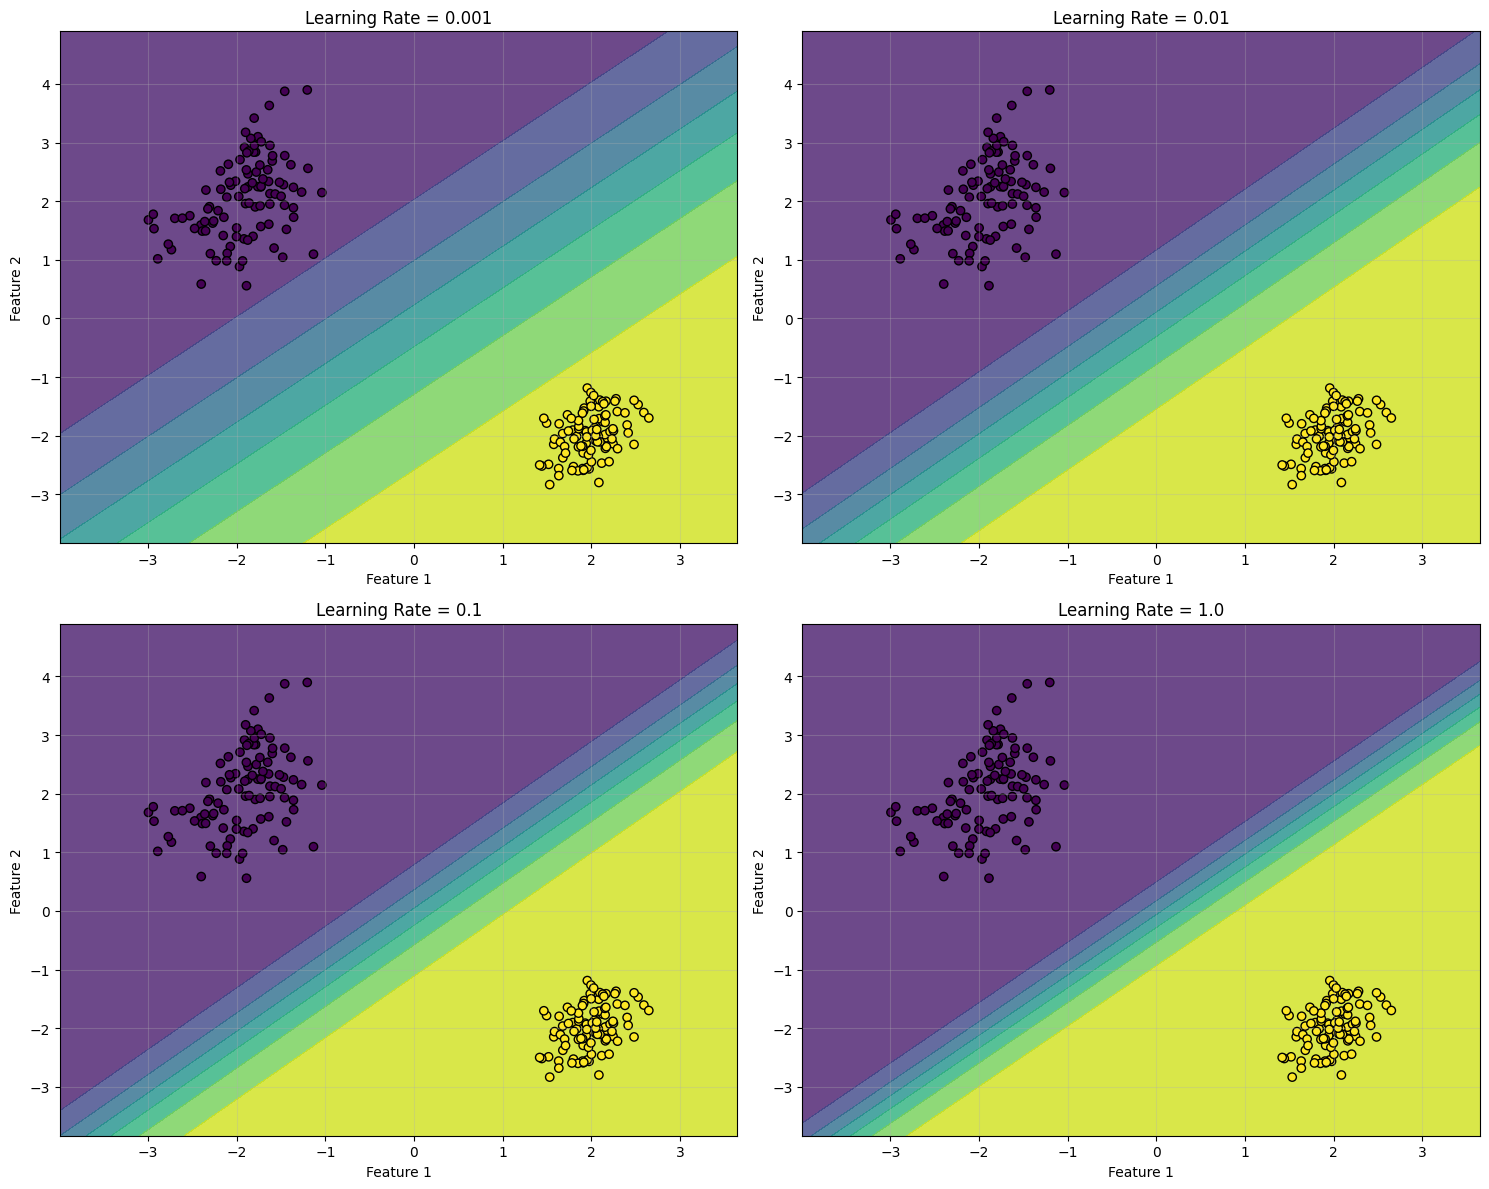

In [13]:
# TODO: Create visualization comparing learning rate effects

# Plot decision boundaries for different learning rates
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, lr in enumerate(learning_rates):
    model = experiment_results[lr]['model']
    
    # Create a mesh grid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    
    # Get predictions for each point in the mesh
    Z = np.zeros(xx.shape)
    for j in range(xx.shape[0]):
        for k in range(xx.shape[1]):
            point = torch.tensor([xx[j, k], yy[j, k]], dtype=torch.float32)
            Z[j, k] = model.forward(point).item()
    
    # Plot decision boundary
    axes[i].contourf(xx, yy, Z, alpha=0.8, cmap='viridis')
    axes[i].scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='k')
    axes[i].set_title(f'Learning Rate = {lr}')
    axes[i].set_xlabel('Feature 1')
    axes[i].set_ylabel('Feature 2')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

3. Analyze and document your findings
    - Compare convergence speed and final accuracy
    - Identify the optimal learning rate for this dataset

In [14]:
# TODO: Add code to print analysis of learning rate effects

# Analysis of results
print("\nAnalysis of Learning Rate Effects:")
for lr, result in experiment_results.items():
    final_accuracy = result['accuracies'][-1]
    convergence_epoch = next((i for i, acc in enumerate(result['accuracies']) 
                              if acc > 95), len(result['accuracies']))
    
    print(f"Learning Rate {lr}:")
    print(f"  Final Accuracy: {final_accuracy:.2f}%")
    if convergence_epoch < len(result['accuracies']):
        print(f"  Converged at epoch {convergence_epoch}")
    else:
        print(" Did not converge to >95% accuracy")
    print()   


Analysis of Learning Rate Effects:
Learning Rate 0.001:
  Final Accuracy: 100.00%
  Converged at epoch 0

Learning Rate 0.01:
  Final Accuracy: 100.00%
  Converged at epoch 0

Learning Rate 0.1:
  Final Accuracy: 100.00%
  Converged at epoch 0

Learning Rate 1.0:
  Final Accuracy: 100.00%
  Converged at epoch 0



**💡 Tip:** Too small a learning rate might cause slow convergence, while too large a learning rate might cause oscillation or divergence.

**⚙️ Test Your Work:**

- You should be able to clearly see differences in learning curves for different rates
- At least one learning rate should lead to good convergence
- Extreme learning rates (very small or very large) should show suboptimal behavior

## ✅ Success Checklist
- Successfully generated and visualized a synthetic dataset
- Implemented a perceptron model from scratch using PyTorch tensors
- Created a functional training loop using the perceptron learning rule
- Visualized the decision boundary and how it evolves during training
- Experimented with different learning rates and analyzed their impact
- Achieved high accuracy (>90%) on the synthetic dataset
- Documented findings and insights from the experiments

## 🔍 Common Issues & Solutions
**Problem:** Model accuracy doesn't improve during training **Solution:** Check if your weight updates are being applied correctly. Make sure your learning rate isn't too small, and verify that your synthetic dataset is indeed linearly separable.

**Problem:** Visualizations are blank or incorrect **Solution:** Ensure your data ranges are appropriate for plotting. Check that your tensor-to-numpy conversions are handling data types correctly.

**Problem:** Training seems unstable or diverges **Solution:** Your learning rate might be too high. Try reducing it by an order of magnitude. Also verify that you're not overshooting the minimum during weight updates.

**Problem:** Your model achieves high training accuracy but decision boundary looks wrong **Solution:** Double-check your decision boundary visualization code. Make sure you're using the correct weights and covering an appropriate range in your mesh grid.

## 🔑 Key Points
- The perceptron is the fundamental building block of neural networks, capable of learning linear decision boundaries
- The perceptron learning rule adjusts weights based on prediction errors to minimize misclassifications
- Learning rate selection significantly impacts training speed and final model performance
- Visualization is a powerful tool for understanding model behavior and debugging issues

## 💻 Reference Solution

<details>

<summary><strong>Click HERE to see a reference solution</strong></summary>    
    
```python
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.datasets import make_classification

# Task 1: Dataset Setup
# Generate synthetic dataset
X_np, y_np = make_classification(
    n_samples=200, 
    n_features=2, 
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1, 
    class_sep=2,
    random_state=88
)

# Convert to PyTorch tensors
X = torch.tensor(X_np, dtype=torch.float32)
y = torch.tensor(y_np, dtype=torch.float32)

# Visualize dataset
plt.figure(figsize=(10, 6))
for class_value in np.unique(y_np):
    plt.scatter(
        X_np[y_np == class_value, 0],
        X_np[y_np == class_value, 1],
        label=f'Class {class_value}',
        edgecolors='k'
    )

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Binary Classification Dataset')
plt.legend() 
plt.grid(True, alpha=0.3)
plt.show()
    
# Task 2: Implementing the Perceptron
class Perceptron:
    def __init__(self, input_dim, learning_rate=0.01):
        # Initialize weights and bias
        self.weights = torch.randn(input_dim, requires_grad=False) * 0.01
        self.bias = torch.zeros(1, requires_grad=False)
        self.learning_rate = learning_rate
        
    def forward(self, x):
        # Calculate the weighted sum and apply activation
        weighted_sum = torch.dot(self.weights, x) + self.bias
        return torch.sigmoid(weighted_sum)
    
    def predict(self, x):
        # Make binary prediction
        return 1 if self.forward(x) >= 0.5 else 0
    
    def update(self, x, target):
        # Calculate prediction and error
        prediction = self.forward(x)
        error = target - prediction
        
        # Update weights and bias using perceptron learning rule
        self.weights += self.learning_rate * error * x
        self.bias += self.learning_rate * error

# Task 3: Training the Perceptron
def train_perceptron(model, X, y, epochs=20):
    accuracies = []
    stored_weights = []
    
    for epoch in range(epochs):
        # Create a permutation for shuffling
        indices = torch.randperm(len(X))
        
        # Training loop
        for i in indices:
            model.update(X[i], y[i])
        
        # Calculate and store accuracy
        accuracy = calculate_accuracy(model, X, y)
        accuracies.append(accuracy)
        
        # Store weights every 10 epochs
        if epoch % 2 == 0:
            stored_weights.append((epoch, model.weights.clone(), model.bias.clone()))
        
        if epoch % 2 == 0:
            print(f"Epoch {epoch}: Accuracy = {accuracy:.2f}%")
    
    return accuracies, stored_weights
    
def calculate_accuracy(model, X, y):
    correct = 0
    for i in range(len(X)):
        pred = model.predict(X[i])
        if pred == y[i]:
            correct += 1
    return correct / len(X) * 100

# Initialize and train perceptron
perceptron = Perceptron(input_dim=2, learning_rate=0.05)
accuracies, stored_weights = train_perceptron(perceptron, X, y)

# Plot accuracy over epochs
plt.figure(figsize=(10, 6))
plt.plot(accuracies)
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Perceptron Training Progress')
plt.grid(True)
plt.show()

# Task 4: Decision Boundary Visualization
def plot_decision_boundary(model, X, y, title="Decision Boundary"):
    # Create a mesh grid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    
    # Get predictions for each point in the mesh
    Z = np.zeros(xx.shape)
    for i in range(xx.shape[0]):
        for j in range(xx.shape[1]):
            point = torch.tensor([xx[i, j], yy[i, j]], dtype=torch.float32)
            Z[i, j] = model.forward(point).item()
    
    # Plot decision boundary
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap='viridis')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='k')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.colorbar()
    plt.show()

# Plot final decision boundary
plot_decision_boundary(perceptron, X_np, y_np)

# Visualize weight evolution
def plot_weight_evolution(stored_weights):
    epochs = [item[0] for item in stored_weights]
    w1_values = [item[1][0].item() for item in stored_weights]
    w2_values = [item[1][1].item() for item in stored_weights]
    bias_values = [item[2].item() for item in stored_weights]
    
    plt.figure(figsize=(12, 6))
    plt.plot(epochs, w1_values, 'o-', label='Weight 1')
    plt.plot(epochs, w2_values, 's-', label='Weight 2')
    plt.plot(epochs, bias_values, '^-', label='Bias')
    plt.xlabel('Epoch')
    plt.ylabel('Value')
    plt.title('Weight Evolution During Training')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_weight_evolution(stored_weights)

# Task 5: Experimentation with Learning Rates
def experiment_with_learning_rates(X, y, learning_rates):
    results = {}
    
    for lr in learning_rates:
        print(f"\nTraining with learning rate: {lr}")
        model = Perceptron(input_dim=2, learning_rate=lr)
        accuracies, _ = train_perceptron(model, X, y, epochs=20)
        results[lr] = {
            'model': model,
            'accuracies': accuracies
        }
    
    return results

# Run experiments with different learning rates
learning_rates = [0.001, 0.01, 0.1, 1.0]
experiment_results = experiment_with_learning_rates(X, y, learning_rates)

# Plot comparison of learning rates
plt.figure(figsize=(12, 8))
for lr, result in experiment_results.items():
    plt.plot(result['accuracies'], label=f'LR = {lr}')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Effect of Learning Rate on Training')
plt.legend()
plt.grid(True)
plt.show()

# Plot decision boundaries for different learning rates
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, lr in enumerate(learning_rates):
    model = experiment_results[lr]['model']
    
    # Create a mesh grid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    
    # Get predictions for each point in the mesh
    Z = np.zeros(xx.shape)
    for j in range(xx.shape[0]):
        for k in range(xx.shape[1]):
            point = torch.tensor([xx[j, k], yy[j, k]], dtype=torch.float32)
            Z[j, k] = model.forward(point).item()
    
    # Plot decision boundary
    axes[i].contourf(xx, yy, Z, alpha=0.8, cmap='viridis')
    axes[i].scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='k')
    axes[i].set_title(f'Learning Rate = {lr}')
    axes[i].set_xlabel('Feature 1')
    axes[i].set_ylabel('Feature 2')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Analysis of results
print("\nAnalysis of Learning Rate Effects:")
for lr, result in experiment_results.items():
    final_accuracy = result['accuracies'][-1]
    convergence_epoch = next((i for i, acc in enumerate(result['accuracies']) 
                              if acc > 95), len(result['accuracies']))
    
    print(f"Learning Rate {lr}:")
    print(f"  Final Accuracy: {final_accuracy:.2f}%")
    if convergence_epoch < len(result['accuracies']):
        print(f"  Converged at epoch {convergence_epoch}")
    else:
        print(" Did not converge to >95% accuracy")
    print()   
```    